# Exploración de `data`

## Importación de librerías y datos

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

In [12]:
data = pd.read_csv("../../data/processed/data.csv")

In [13]:
print(f"Registros: {data.shape[0]}\nColumnas: {data.shape[1]}\n")
print(f"Columnas: {data.columns}\n")

Registros: 99455
Columnas: 5

Columnas: Index(['user_id', 'item_id', 'rating', 'timestamp', 'datetime'], dtype='str')



## Estadísticas y visualizaciones

In [14]:
def print_stats(serie, label):
    print(f"--- {label} ---")
    print(f"Mínimo:  {serie.min():.2f}")
    print(f"Máximo:  {serie.max():.2f}")
    print(f"Mediana: {serie.median():.2f}")
    print(f"Media:   {serie.mean():.2f}")

### Distribución de películas calificadas por usuario


--- Películas calificadas por usuario ---
Mínimo:  19.00
Máximo:  734.00
Mediana: 64.00
Media:   105.47


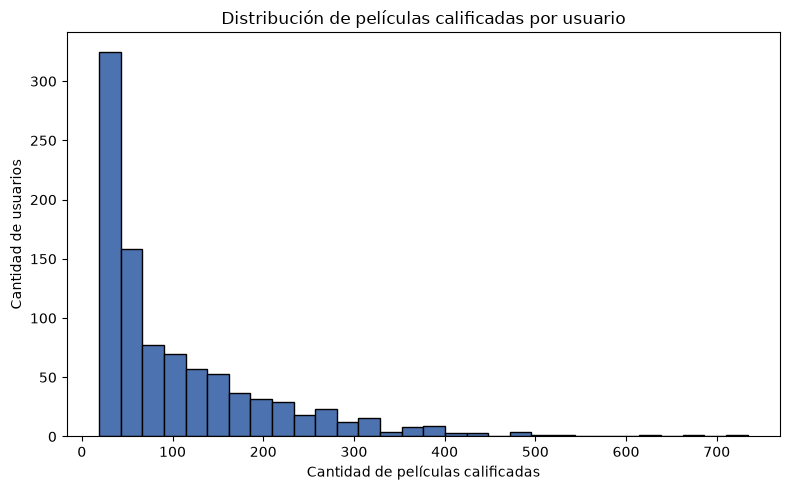

In [15]:
ratings_per_user = data.groupby('user_id')['item_id'].count()
print_stats(ratings_per_user, "Películas calificadas por usuario")

plt.figure(figsize=(8, 5))
plt.hist(ratings_per_user, bins=30, color="#4C72B0", edgecolor="black")
plt.xlabel("Cantidad de películas calificadas")
plt.ylabel("Cantidad de usuarios")
plt.title("Distribución de películas calificadas por usuario")
plt.tight_layout()
plt.show()

### Distribución de calificaciones por película


--- Calificaciones por película ---
Mínimo:  1.00
Máximo:  583.00
Mediana: 27.00
Media:   59.88


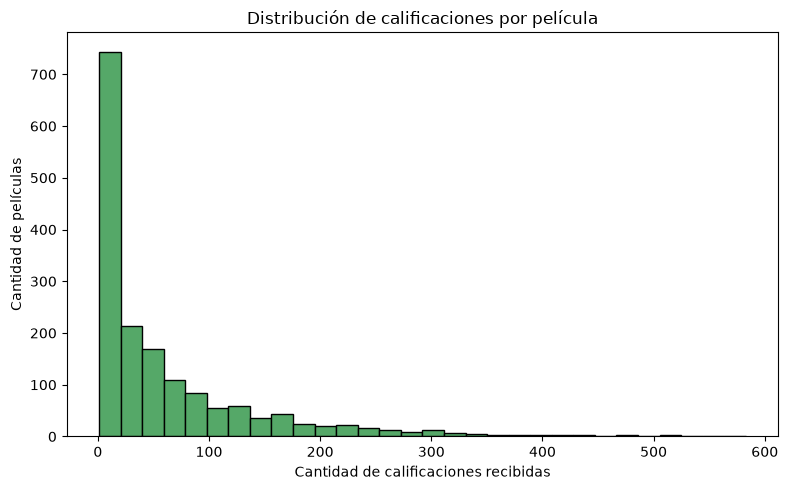

In [16]:
ratings_per_movie = data.groupby('item_id')['user_id'].count()
print_stats(ratings_per_movie, "Calificaciones por película")

plt.figure(figsize=(8, 5))
plt.hist(ratings_per_movie, bins=30, color="#55A868", edgecolor="black")
plt.xlabel("Cantidad de calificaciones recibidas")
plt.ylabel("Cantidad de películas")
plt.title("Distribución de calificaciones por película")
plt.tight_layout()
plt.show()

### Distribución de calificaciones

In [17]:
rating_counts = data['rating'].value_counts().sort_index()
rating_props = data['rating'].value_counts(normalize=True).sort_index()

rating_summary = pd.DataFrame({
    "conteo": rating_counts,
    "proporcion": rating_props.round(4)
})
rating_summary

,conteo,proporcion
rating,,
1,6065,0.0610
2,11326,0.1139
3,27028,0.2718
4,33976,0.3416
5,21060,0.2118


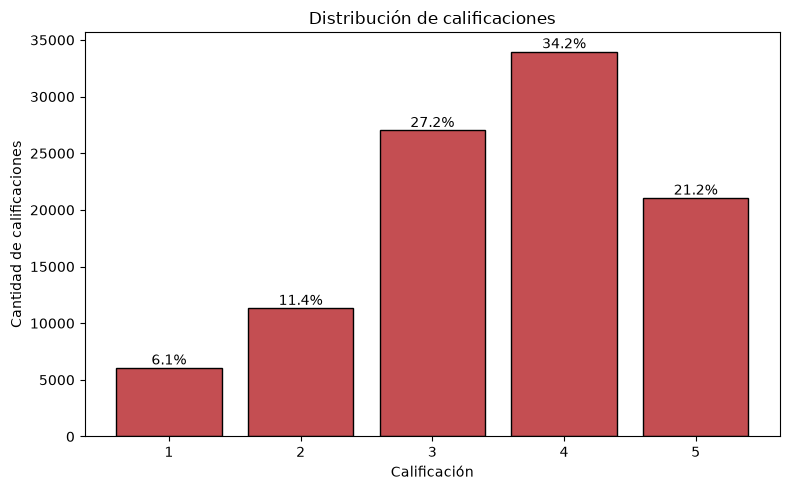

In [18]:
fig, ax1 = plt.subplots(figsize=(8, 5))

bars = ax1.bar(rating_counts.index, rating_counts.values, color="#C44E52", edgecolor="black")
ax1.set_xlabel("Calificación")
ax1.set_ylabel("Cantidad de calificaciones")
ax1.set_title("Distribución de calificaciones")
ax1.set_xticks(rating_counts.index)

for bar, prop in zip(bars, rating_props.values):
    ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
             f"{prop:.1%}", ha="center", va="bottom")

plt.tight_layout()
plt.show()

### Distribución de calificación promedio por usuario

--- Calificación promedio por usuario ---
Mínimo:  1.50
Máximo:  4.87
Mediana: 3.62
Media:   3.59


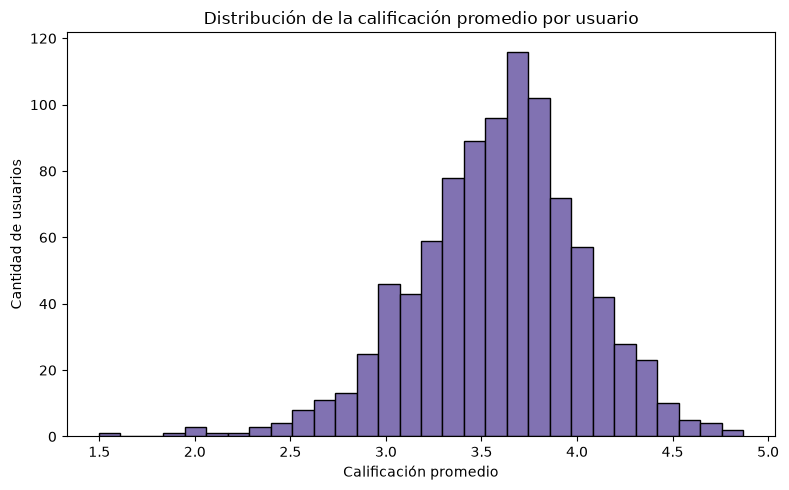

In [19]:
avg_rating_per_user = data.groupby('user_id')['rating'].mean()
print_stats(avg_rating_per_user, "Calificación promedio por usuario")

plt.figure(figsize=(8, 5))
plt.hist(avg_rating_per_user, bins=30, color="#8172B2", edgecolor="black")
plt.xlabel("Calificación promedio")
plt.ylabel("Cantidad de usuarios")
plt.title("Distribución de la calificación promedio por usuario")
plt.tight_layout()
plt.show()

### Distribución de calificación promedio por película

--- Calificación promedio por película ---
Mínimo:  1.00
Máximo:  5.00
Mediana: 3.16
Media:   3.08


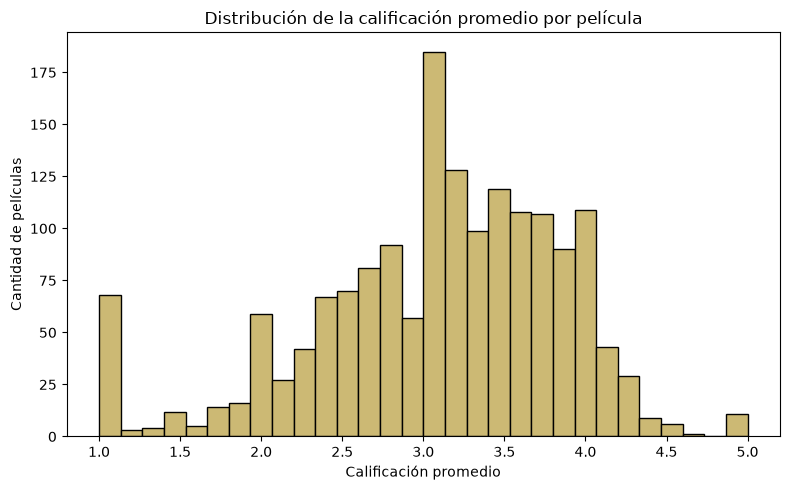

In [20]:
avg_rating_per_movie = data.groupby('item_id')['rating'].mean()
print_stats(avg_rating_per_movie, "Calificación promedio por película")

plt.figure(figsize=(8, 5))
plt.hist(avg_rating_per_movie, bins=30, color="#CCB974", edgecolor="black")
plt.xlabel("Calificación promedio")
plt.ylabel("Cantidad de películas")
plt.title("Distribución de la calificación promedio por película")
plt.tight_layout()
plt.show()